# 09 — iGEM village awards: clusters and outsiderness

**Question.** Do iGEM's *village awards* line up with the joint-map structure the
rest of this repo is built on — the **precedence clusters** (where iGEM leads or
lags the literature) and each team's **outsiderness** (how sparse the literature
was where it worked)?

**Award scope.** We keep only rows with `AwardDecision = winner` **and**
`AwardType = village` from `00-IGEM_teams_dataset/team_awards.tsv`. Village awards
are the *"Best <Track> Project"* prizes (Best Therapeutics, Best Foundational
Advance, Best Environment, …), handed out one per track per year since 2014. Each
winner is a distinct team, so the set is **197 winning teams, 2014–2025**.

**How a team is placed on the map.** The award file keys teams by `TeamID`, which
is exactly the `UT` id used everywhere else in `assets/reports/`, so every winner
joins cleanly (197/197) to:

- `teams_topic_hierarchy_map` — its micro / meso / macro topic (its *home* cluster);
- `joint_umap_teams_xy` — its `(x, y)` in the shared UMAP;
- `geography_outsiderness_teams` — its contemporaneous **outsiderness**
  (`contemp` = 1 − literature-density percentile at the team's location and year;
  higher = worked where the literature of the day was sparse).

**Two notions of "cluster".** We report both:

1. **Overlap-precedence clusters** (the list the precedence charts use, from
   `overlap_precedence_full.tsv`). For each we count winners with the *same
   spatial-neighbourhood rule* the precedence table uses, so award counts sit in
   the same frame as `delta_*_years`. This answers *do awards concentrate on the
   iGEM-led frontier or the literature-led core?*
2. **Home clusters** (each team's own macro/meso topic). More interpretable for
   *which kinds of project win*, and for a win-rate against the team base.

**Outputs written to `assets/reports/`:** `awards_village_winners.tsv`,
`awards_by_overlap_cluster.tsv`, `awards_by_home_cluster.tsv`,
`awards_outsiderness_by_track.tsv`, `awards_outsiderness.png`.

> Run with the conda `base` interpreter (`/opt/anaconda3/bin/python`), which has
> pandas / scipy / matplotlib / seaborn — the repo `.venv` does not.

## 1  Setup and data loading

In [1]:
# Make the shared aux/ package importable (this notebook lives in 05-reporting/).
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd()))

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.spatial import cKDTree
from scipy.stats import mannwhitneyu, kruskal, spearmanr

from aux.paths import REPORTS_DIR, set_seed
from aux.coords import load_plot_data

set_seed()
pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 40)

# Joint-map frames (coords + hierarchy levels + year), shared with every other notebook.
df_papers, df_teams, XLIM, YLIM = load_plot_data()

# The overlap-precedence clusters — the exact list the precedence charts render.
df_prec = pd.read_csv(REPORTS_DIR / "overlap_precedence_full.tsv", sep="\t")

# Per-team outsiderness (contemporaneous literature field, the PRIMARY score).
outs = pd.read_csv(REPORTS_DIR / "geography_outsiderness_teams.tsv",
                   sep="\t", usecols=["UT", "contemp", "fixed", "ratio"])

print(f"teams frame        : {len(df_teams):,} teams")
print(f"overlap clusters   : {len(df_prec):,}")
print(f"outsiderness scored: {outs['contemp'].notna().sum():,} teams")

teams frame        : 4,707 teams
overlap clusters   : 64
outsiderness scored: 4,707 teams


## 2  The village winners

Filter to `winner` × `village`, then attach each winner's home cluster, map
position, year, and outsiderness. We also tag each winner's **track** with a
coarse orientation (`clinical core` / `engineering frontier` /
`environmental·applied`) — the mapping is spelled out explicitly below so it is
easy to audit or change. It groups *award tracks*, and is used only in §5.

In [3]:
awards = pd.read_csv(REPORTS_DIR.parent.parent / "00-IGEM_teams_dataset" / "team_awards.tsv",
                     sep="\t", dtype=str)

win = awards[(awards["AwardDecision"].str.lower() == "winner")
             & (awards["AwardType"].str.lower() == "village")].copy()
win["UT"] = pd.to_numeric(win["TeamID"], errors="coerce").astype("Int64")

# Track orientation. Everything not clinical/engineering falls to environmental·applied,
# which is the large bucket of Environment, Bioremediation, Food, Manufacturing, Energy, …
CLINICAL = {"Best Therapeutics Project", "Best Diagnostics Project",
            "Best Health & Medicine Project", "Best Oncology Project",
            "Best Infectious Diseases Project"}
ENGINEERING = {"Best Foundational Advance Project", "Best Software Project",
               "Best Software & AI Project", "Best Hardware Project",
               "Best Information Processing Project", "Best Measurement Project",
               "Best Microfluidics Project"}

def track_orientation(title):
    if title in CLINICAL:
        return "clinical core"
    if title in ENGINEERING:
        return "engineering frontier"
    return "environmental·applied"

win["track"] = win["AwardTitle"]
win["orientation"] = win["AwardTitle"].map(track_orientation)

cols = ["UT", "x", "y", "year", "topic", "low_name", "mid", "mid_name", "high", "high_name"]
winners = (win[["UT", "Team", "Year", "track", "orientation"]]
           .merge(df_teams[cols], on="UT", how="left")
           .merge(outs, on="UT", how="left"))

assert winners["x"].notna().all(),        "some winner has no map position"
assert winners["contemp"].notna().all(),  "some winner has no outsiderness"
assert winners["UT"].is_unique,           "a team won more than one village award"

winners.to_csv(REPORTS_DIR / "awards_village_winners.tsv", sep="\t", index=False)
print(f"village winners: {len(winners)}   years {int(winners['Year'].astype(int).min())}"
      f"–{int(winners['Year'].astype(int).max())}   all joined 197/197")
winners.head()

village winners: 197   years 2014–2025   all joined 197/197


,UT,Team,Year,track,orientation,x,y,year,topic,low_name,mid,mid_name,high,high_name,contemp,fixed,ratio
0,1319,Aachen,2014,Best Measurement Project,engineering frontier,1.948818,0.545718,2014,2,Environmental Monitoring and Bioremediation,2,Synthetic Diagnostics and Biosensing Technologies,2,Medical Diagnostics & Therapeutics,0.969667,0.953000,3.427317
1,1352,Aberdeen_Scotland,2014,Best Health & Medicine Project,clinical core,1.792933,0.077668,2014,37,Tropical Disease Diagnostics,2,Synthetic Diagnostics and Biosensing Technologies,2,Medical Diagnostics & Therapeutics,0.949333,0.903667,2.615023
2,1543,ArtCenter_MDP,2014,Best Art & Design Project,environmental·applied,1.046526,3.591435,2014,54,Microalgae Engineering for Sustainability,10,Synthetic Circuits for Sensing and Memory,1,Environmental Bioremediation & Resource Recycling,0.952000,0.863333,2.037134
3,1315,Dundee,2014,Best Health & Medicine Project,clinical core,1.947464,0.513383,2014,138,Bacterial Quorum Sensing Engineering,21,Multicellular Pattern Formation and Communication,0,Advanced Gene Regulation & Synthetic Systems,0.970000,0.951333,3.387544
4,1566,GES_NCSU_Raleigh_NC,2014,Best Policy & Practices Project,environmental·applied,-4.366148,4.901969,2014,49,Environmental and Ecological Synthetic Biology,4,Standardized Biological Parts and Engineering ...,0,Advanced Gene Regulation & Synthetic Systems,0.068667,0.083667,-4.983754


## 3  What the award portfolio looks like

Village awards are a **fixed annual quota** (~16 tracks/year), so the counts below
describe the *shape of the programme*, not a competition intensity. Track
popularity is the number of years a track existed × its share of winners.

In [4]:
per_year = win.groupby("Year").size().rename("winners")
per_track = (winners.groupby("track")
             .agg(winners=("UT", "size"), mean_outsiderness=("contemp", "mean"))
             .sort_values("winners", ascending=False))

print("Winners per year (steady annual quota):")
print(per_year.to_string())
print(f"\nTracks awarded: {winners['track'].nunique()}")
print("\nWinners per track:")
print(per_track.round(3).to_string())

Winners per year (steady annual quota):
Year
2014    19
2015    18
2016    18
2017    17
2018    17
2019    17
2020    16
2021    15
2022    14
2023    15
2024    15
2025    16

Tracks awarded: 30

Winners per track:
                                     winners  mean_outsiderness
track                                                          
Best Foundational Advance Project         20              0.580
Best Environment Project                  20              0.982
Best Therapeutics Project                 19              0.870
Best Diagnostics Project                  18              0.891
Best New Application Project              16              0.809
Best Food & Nutrition Project             15              0.942
Best Manufacturing Project                12              0.841
Best Biomanufacturing Project              8              0.859
Best Software Project                      8              0.773
Best Energy Project                        6              0.945
Best Informatio

## 4  Table A — awards against the overlap-precedence clusters

This is the requested table: **the same cluster list the precedence charts use**,
with award columns appended. For each overlap topic we take its paper-point
centroid and query the teams within `1.5 × median-radius` — *the identical
neighbourhood rule* `aux.precedence.compute_precedence` uses — then count how many
of those nearby teams are village winners.

Because neighbourhoods overlap, a winner can be counted in more than one cluster
(exactly as `n_nearby_teams` already double-counts), so `award_rate =
winners_nearby / teams_nearby` is a *density of decorated teams around the
cluster*, comparable across rows. `delta_q1_years < 0` marks an **iGEM-led
(frontier)** cluster; `> 0` a **literature-led (core)** cluster.

In [5]:
_dp = df_papers[df_papers["topic"] >= 0]
teams_xy = df_teams[["x", "y"]].to_numpy()
teams_tree = cKDTree(teams_xy)
win_ut = set(winners["UT"].astype(int))
is_win = df_teams["UT"].isin(win_ut).to_numpy()
out_by_ut = outs.set_index("UT")["contemp"]

rows = []
for _, r in df_prec.iterrows():
    pts = _dp.loc[_dp["topic"] == r["topic"], ["x", "y"]].to_numpy()
    if len(pts) == 0:
        continue
    cx, cy = np.median(pts[:, 0]), np.median(pts[:, 1])
    radius = np.median(np.hypot(pts[:, 0] - cx, pts[:, 1] - cy)) * 1.5
    idx = np.asarray(teams_tree.query_ball_point([cx, cy], r=radius), dtype=int)
    near_ut = df_teams.iloc[idx]["UT"]
    win_titles = winners.loc[winners["UT"].astype(int).isin(set(near_ut) & win_ut), "track"]
    top = win_titles.value_counts()
    rows.append(dict(
        topic=int(r["topic"]),
        cluster=r["global_name"],
        lead="iGEM-led" if r["delta_q1_years"] < 0 else "literature-led",
        delta_q1_years=r["delta_q1_years"],
        delta_mean_years=r["delta_mean_years"],
        n_papers=int(r["n_papers"]),
        teams_nearby=len(idx),
        winners_nearby=int(is_win[idx].sum()),
        award_rate=round(is_win[idx].sum() / len(idx), 4) if len(idx) else np.nan,
        winners_outsiderness=round(out_by_ut.reindex(near_ut[is_win[idx]]).mean(), 3)
                               if is_win[idx].any() else np.nan,
        top_tracks="; ".join(f"{t}×{n}" for t, n in top.head(3).items()),
    ))

awards_by_cluster = (pd.DataFrame(rows)
                     .sort_values("delta_q1_years")          # same order as the charts
                     .reset_index(drop=True))
awards_by_cluster.to_csv(REPORTS_DIR / "awards_by_overlap_cluster.tsv", sep="\t", index=False)

n_with = (awards_by_cluster["winners_nearby"] > 0).sum()
print(f"{len(awards_by_cluster)} overlap clusters — {n_with} have >=1 village winner in "
      f"their neighbourhood.\n")
awards_by_cluster

64 overlap clusters — 32 have >=1 village winner in their neighbourhood.



,topic,cluster,lead,delta_q1_years,delta_mean_years,n_papers,teams_nearby,winners_nearby,award_rate,winners_outsiderness,top_tracks
0,163,Biological Computation and Logic,iGEM-led,-7.00,-5.07,27,5,0,0.0000,NaN,
1,127,Genetic Logic and Memory Devices,iGEM-led,-6.00,-6.20,36,32,0,0.0000,NaN,
2,194,Microbial Bioproduction and Stress Tolerance,iGEM-led,-6.00,-2.45,23,85,0,0.0000,NaN,
3,86,Peptide Biosynthesis and Engineering,iGEM-led,-5.75,-6.64,49,6,0,0.0000,NaN,
4,110,Magnetic Bioengineering,iGEM-led,-4.25,-3.90,40,20,1,0.0500,0.982,Best Foundational Advance Project×1
...,...,...,...,...,...,...,...,...,...,...,...
59,66,Pathogen Synthetic Biology,literature-led,8.50,4.29,59,8,0,0.0000,NaN,
60,183,Cancer Gene Regulation,literature-led,10.00,7.05,25,3,1,0.3333,0.430,Best Oncology Project×1
61,151,HCV Synthetic Biology,literature-led,10.25,6.47,30,6,0,0.0000,NaN,
62,116,Gene Regulation and Therapeutics,literature-led,10.50,7.01,39,54,3,0.0556,0.607,Best Therapeutics Project×2; Best Oncology Pro...


### Does the award density track the frontier↔core axis?

If the establishment rewarded the iGEM-led frontier (or, conversely, the
literature-led clinical core) we would see `award_rate` slope with
`delta_q1_years`. It does not.

In [6]:
sub = awards_by_cluster[awards_by_cluster["teams_nearby"] >= 3]
rho_rate, p_rate = spearmanr(sub["delta_q1_years"], sub["award_rate"])
rho_n, p_n = spearmanr(sub["delta_q1_years"], sub["winners_nearby"])

grp = (awards_by_cluster.assign(side=np.where(awards_by_cluster["delta_mean_years"] < 0,
                                              "iGEM-led (frontier)", "literature-led (core)"))
       .groupby("side")
       .agg(clusters=("topic", "size"), winners=("winners_nearby", "sum"),
            teams=("teams_nearby", "sum")))
grp["award_rate"] = (grp["winners"] / grp["teams"]).round(4)

print(f"Spearman  award_rate  vs delta_q1_years : rho={rho_rate:+.3f}  p={p_rate:.3f}")
print(f"Spearman  winners_nearby vs delta_q1_years : rho={rho_n:+.3f}  p={p_n:.3f}")
print("\nAward density is essentially flat across the precedence axis:")
print(grp.to_string())

Spearman  award_rate  vs delta_q1_years : rho=-0.113  p=0.372
Spearman  winners_nearby vs delta_q1_years : rho=-0.156  p=0.219

Award density is essentially flat across the precedence axis:
                       clusters  winners  teams  award_rate
side                                                       
iGEM-led (frontier)          37       52   1628      0.0319
literature-led (core)        27       18    500      0.0360


## 5  Table B — awards against each team's *home* cluster

The neighbourhood view above only sees the overlap band. A team's **home macro /
meso cluster** places every winner, and lets us compare a cluster's share of
*winners* against its share of *all teams* (`win_rate`). A quota spread evenly
would give a flat win-rate; a cluster the judges favour would rise above the base
rate.

In [7]:
def home_table(level_name):
    base = df_teams.groupby(level_name).size().rename("teams")
    won = winners.groupby(level_name).agg(winners=("UT", "size"),
                                          mean_outsiderness=("contemp", "mean"))
    t = won.join(base)
    t["win_rate"] = (t["winners"] / t["teams"]).round(4)
    return t.sort_values("winners", ascending=False)

macro = home_table("high_name")
macro.to_csv(REPORTS_DIR / "awards_by_home_cluster.tsv", sep="\t")
base_rate = len(winners) / len(df_teams)
print(f"Overall village-win base rate: {base_rate:.3f} of teams\n")
print("Macro (high-level) home clusters:")
print(macro.round(3).to_string())

Overall village-win base rate: 0.042 of teams

Macro (high-level) home clusters:
                                                             winners  mean_outsiderness  teams  win_rate
high_name                                                                                               
Advanced Gene Regulation & Synthetic Systems                      55              0.679   1339     0.041
Biomedical and Environmental Synthetic Biology Applications       53              0.923   1427     0.037
Environmental Bioremediation & Resource Recycling                 52              0.951   1252     0.042
Medical Diagnostics & Therapeutics                                37              0.848    689     0.054


In [8]:
meso = home_table("mid_name")
print("Meso (mid-level) home clusters with >=5 winners:")
print(meso[meso["winners"] >= 5].round(3).to_string())

Meso (mid-level) home clusters with >=5 winners:
                                                             winners  mean_outsiderness  teams  win_rate
mid_name                                                                                                
Synthetic Diagnostics and Biosensing Technologies                 26              0.902    428     0.061
Advanced Gene Regulation and Synthetic Systems                    24              0.687    730     0.033
Agricultural and Ecological Synthetic Biology                     12              0.956    167     0.072
Standardized Biological Parts and Engineering Platforms           10              0.639    163     0.061
Environmental and Agricultural Bioengineering                      8              0.889    161      0.05
Antimicrobial and Microbial Engineering                            8              0.881    189     0.042
Biodegradation and Environmental Bioremediation                    8              0.991    188     0.043
Sustai

## 6  Awards and outsiderness

### 6.1  Pooled: are winners insiders or outsiders?

Compared against the full team population (and against village *nominees*), village
winners are **statistically indistinguishable** in outsiderness. Winning is not, by
itself, tilted toward the literature-dense core or the sparse periphery.

In [9]:
all_out = df_teams[["UT"]].merge(outs, on="UT", how="left")["contemp"].dropna()
win_out = winners["contemp"].dropna()

nominee = awards[(awards["AwardDecision"].str.lower() == "nominee")
                 & (awards["AwardType"].str.lower() == "village")].copy()
nominee["UT"] = pd.to_numeric(nominee["TeamID"], errors="coerce")
nom_out = nominee.merge(outs, on="UT", how="left")["contemp"].dropna()

u, p = mannwhitneyu(win_out, all_out, alternative="two-sided")
print(f"outsiderness (contemporaneous)   mean   median     n")
print(f"  all teams   {all_out.mean():.3f}  {all_out.median():.3f}   {all_out.size}")
print(f"  nominees    {nom_out.mean():.3f}  {nom_out.median():.3f}   {nom_out.size}")
print(f"  winners     {win_out.mean():.3f}  {win_out.median():.3f}   {win_out.size}")
print(f"\nMann–Whitney winners vs all teams: U={u:.0f}  p={p:.3f}  "
      f"({'no difference' if p > 0.05 else 'differs'})")

outsiderness (contemporaneous)   mean   median     n
  all teams   0.833  0.928   4707
  nominees    0.841  0.935   401
  winners     0.848  0.938   197

Mann–Whitney winners vs all teams: U=472246  p=0.658  (no difference)


### 6.2  By track: the award *portfolio* spans the whole outsiderness range

The pooled null hides the real structure. Because awards are organised **by
village track**, and tracks sit in very different regions of the joint map, the
winners' outsiderness runs almost the full 0–1 range in a clean, orderly
gradient:

- **engineering / foundational** tracks (Foundational Advance, Software,
  Information Processing) sit where the *synbio* literature is **densest** — low
  outsiderness. These are the mature core of the field's own literature, the very
  frontier iGEM reached first and the literature later filled in.
- **clinical** tracks (Therapeutics, Diagnostics) sit at **moderate–high**
  outsiderness: the synbio-OpenAlex corpus is thin there (clinical work lives in
  the medical literature), which is the same "resource-gated core iGEM lags" seen
  in the precedence results.
- **environmental / applied** tracks (Environment, Bioremediation, Conservation)
  sit where the literature is **sparsest** — the highest outsiderness.

A Kruskal–Wallis test across the three orientations, and a direct
clinical-vs-engineering contrast, are both significant.

In [10]:
by_track = (winners.groupby(["orientation", "track"])
            .agg(winners=("UT", "size"), mean_outsiderness=("contemp", "mean"),
                 median_outsiderness=("contemp", "median"))
            .sort_values("mean_outsiderness"))
by_track.round(3).to_csv(REPORTS_DIR / "awards_outsiderness_by_track.tsv", sep="\t")
print("Per-track outsiderness (ascending — insider tracks first):")
print(by_track.round(3).to_string())

groups = [g["contemp"].values for _, g in winners.groupby("orientation")]
h, p_kw = kruskal(*groups)
cc = winners.loc[winners["orientation"] == "clinical core", "contemp"]
ef = winners.loc[winners["orientation"] == "engineering frontier", "contemp"]
u2, p_mw = mannwhitneyu(cc, ef, alternative="two-sided")

print(f"\nOrientation means:")
print(winners.groupby("orientation")["contemp"].agg(["size", "mean", "median"]).round(3).to_string())
print(f"\nKruskal–Wallis across orientations : H={h:.2f}  p={p_kw:.4f}")
print(f"Mann–Whitney clinical vs engineering: U={u2:.0f}  p={p_mw:.4f}")

Per-track outsiderness (ascending — insider tracks first):
                                                           winners  mean_outsiderness  median_outsiderness
orientation           track                                                                               
environmental·applied Best Policy & Practices Project            1              0.069                0.069
engineering frontier  Best Foundational Advance Project         20              0.580                0.567
clinical core         Best Oncology Project                      2              0.638                0.638
engineering frontier  Best Hardware Project                      3              0.701                0.657
                      Best Software Project                      8              0.773                0.825
environmental·applied Best Agriculture Project                   3              0.785                0.950
engineering frontier  Best Information Processing Project        6              0.794

### 6.3  Figure — outsiderness of winners, pooled and by track

/var/folders/l3/ykgptl812qndpwdm6n3tm9jr0000gn/T/ipykernel_55169/2777770560.py:26: RuntimeWarning: Engine has switched to 'python' because numexpr does not support extension array dtypes. Please set your engine to python manually.
  .query("n >= 4").sort_values("m"))


Saved → /Users/cristian/Desktop/GitHub/igem-synbio/assets/reports/awards_outsiderness.png


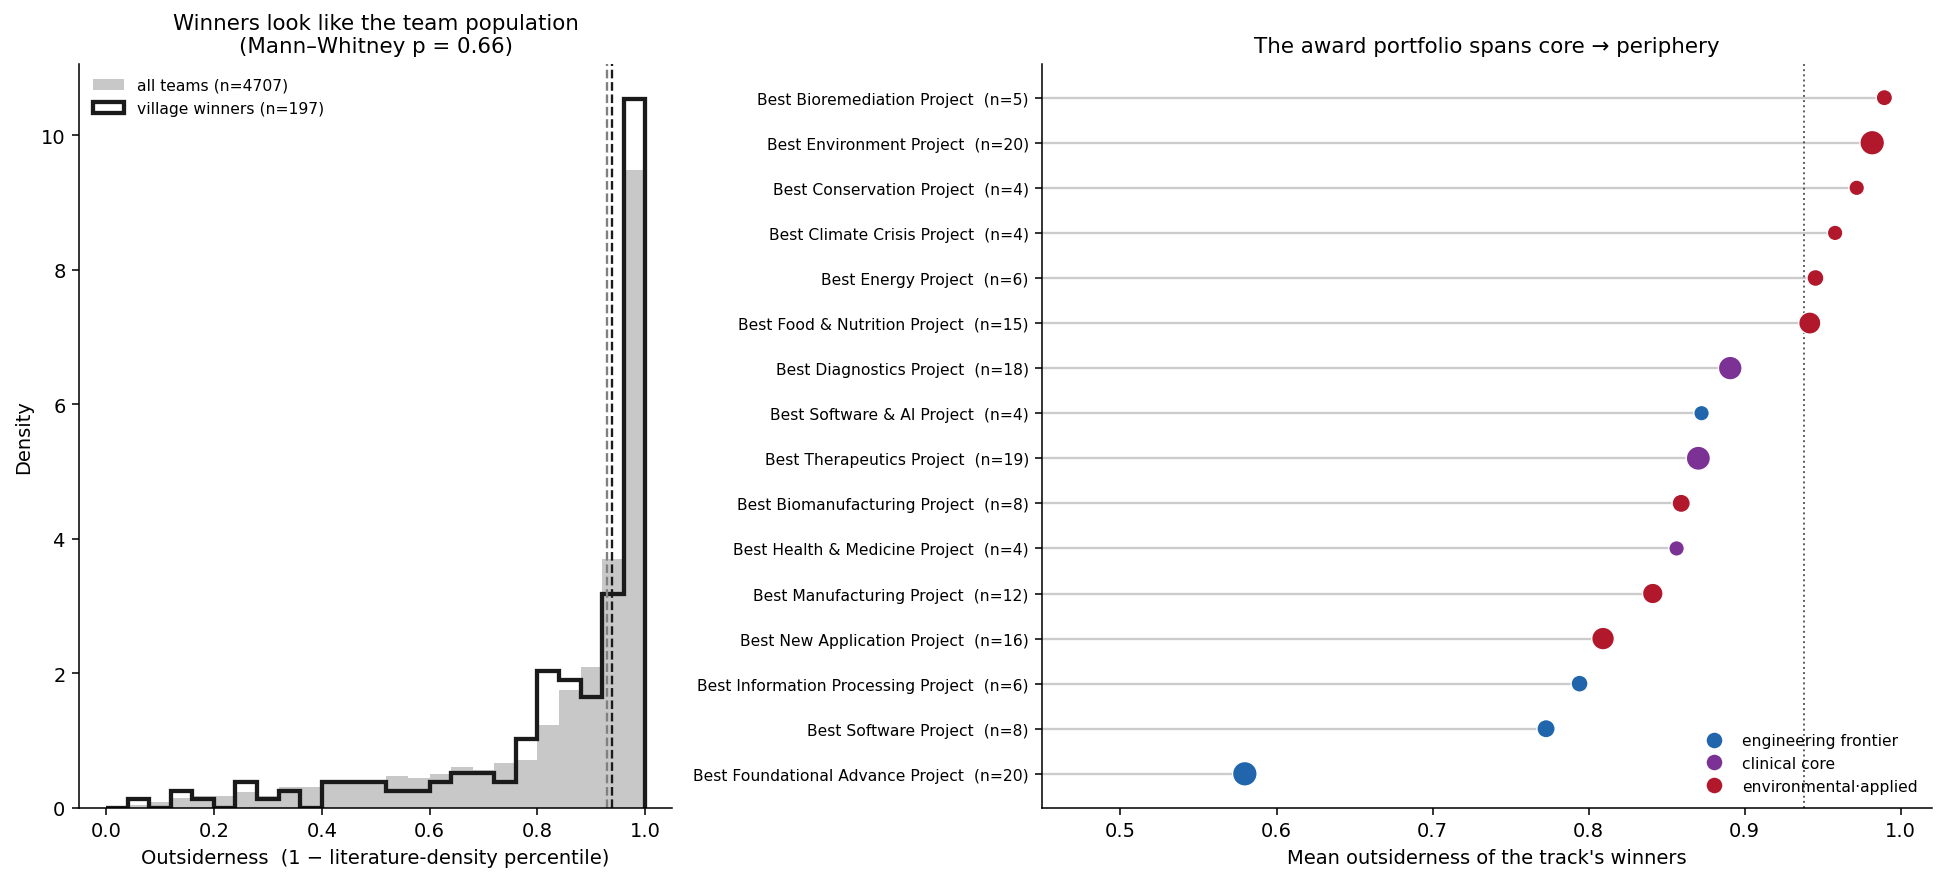

In [11]:
RED, BLUE, INK = "#b2182b", "#2166ac", "#1a1a1a"
ORI_COLOR = {"engineering frontier": BLUE, "clinical core": "#7b3294",
             "environmental·applied": RED}

fig, (axL, axR) = plt.subplots(1, 2, figsize=(14, 6.4), dpi=140,
                               gridspec_kw=dict(width_ratios=[1, 1.5]))

# Left: winners vs all teams — the pooled null.
bins = np.linspace(0, 1, 26)
axL.hist(all_out, bins=bins, density=True, color="0.75", alpha=0.85, label=f"all teams (n={all_out.size})")
axL.hist(win_out, bins=bins, density=True, histtype="step", color=INK, lw=2.2,
         label=f"village winners (n={win_out.size})")
axL.axvline(all_out.median(), color="0.5", lw=1.2, ls="--")
axL.axvline(win_out.median(), color=INK, lw=1.2, ls="--")
axL.set_xlabel("Outsiderness  (1 − literature-density percentile)")
axL.set_ylabel("Density")
axL.set_title(f"Winners look like the team population\n(Mann–Whitney p = {p:.2f})", fontsize=11)
axL.legend(fontsize=8, frameon=False, loc="upper left")
for s in ("top", "right"):
    axL.spines[s].set_visible(False)

# Right: per-track means, ordered, coloured by orientation — the real gradient.
tk = (winners.groupby("track")
      .agg(m=("contemp", "mean"), n=("UT", "size"),
           orientation=("orientation", "first"))
      .query("n >= 4").sort_values("m"))
yv = np.arange(len(tk))
axR.hlines(yv, 0, tk["m"], color="0.8", lw=1.2, zorder=1)
axR.scatter(tk["m"], yv, s=40 + 6 * tk["n"], zorder=3,
            c=[ORI_COLOR[o] for o in tk["orientation"]], edgecolor="white", linewidth=0.7)
axR.axvline(win_out.median(), color=INK, lw=1.0, ls=":", alpha=0.7)
axR.set_yticks(yv)
axR.set_yticklabels([f"{t}  (n={n})" for t, n in zip(tk.index, tk["n"])], fontsize=8)
axR.set_xlabel("Mean outsiderness of the track's winners")
axR.set_title("The award portfolio spans core → periphery", fontsize=11)
axR.set_xlim(0.45, 1.02)
from matplotlib.lines import Line2D
handles = [Line2D([], [], marker="o", ls="", mec="white", mfc=c, ms=9, label=o)
           for o, c in ORI_COLOR.items()]
axR.legend(handles=handles, fontsize=8, frameon=False, loc="lower right")
for s in ("top", "right"):
    axR.spines[s].set_visible(False)

fig.tight_layout()
fig.savefig(REPORTS_DIR / "awards_outsiderness.png", dpi=180, bbox_inches="tight")
print(f"Saved → {REPORTS_DIR / 'awards_outsiderness.png'}")
plt.show()

## 7  Findings

1. **Awards are outsiderness-neutral overall.** Village winners are
   indistinguishable from the general team population, and from village nominees,
   in contemporaneous outsiderness (Mann–Whitney *p* ≈ 0.66). Being decorated
   does not mean sitting closer to — or farther from — the literature.

2. **Awards do not concentrate on the frontier or the core.** Mapped onto the
   overlap-precedence clusters with the precedence code's own neighbourhood rule,
   the density of winners is flat across the frontier↔core axis (Spearman of
   `award_rate` on `delta_q1_years` ≈ −0.11, *p* ≈ 0.37; iGEM-led vs
   literature-led clusters award at ~0.032 vs ~0.036). The village prize structure
   is, by construction, a **spread quota** rather than a spotlight on iGEM's
   leading edge.

3. **Win-rate is near-flat across home macro-clusters** (~0.037–0.054 of teams),
   highest in *Medical Diagnostics & Therapeutics* — consistent with a fixed
   per-track quota rather than judges favouring one region of the map.

4. **The real signal is by track, and it recovers the paper's core→periphery
   geometry.** Winners' outsiderness runs a clean gradient from
   ~0.58 (Best Foundational Advance) to ~0.99 (Best Environment / Bioremediation);
   the engineering-vs-clinical contrast is significant (*p* ≈ 0.002),
   Kruskal–Wallis across the three orientations likewise. The award *portfolio*
   therefore samples the whole joint map — the literature-dense engineering core
   iGEM reached first, and the literature-sparse environmental periphery — which is
   the same outside-in geometry the precedence and geography results describe,
   now visible in iGEM's own recognition system.

**Bottom line for the manuscript.** Village awards are not a competitive signal of
outsiderness — the quota washes that out — but they are a useful, independent
*labelling* of where teams work: the award taxonomy itself lines up with the
core→periphery axis, giving a human-curated cross-check on the density-based
outsiderness score.